# 01 — Exploratory Data Analysis

Produces Figure 1 (class distribution) and Figure 7 (feature distributions).

**Prerequisite:** Run `00_dataset_prep.ipynb` first.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

DATA_DIR    = os.path.join('..', 'data')
FIGURES_DIR = os.path.join('..', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

SIGNAL_COLOR     = '#534AB7'
BACKGROUND_COLOR = '#0F6E56'

In [2]:
versions = {}
for v in ['A', 'B', 'C']:
    try:
        train = pd.read_csv(os.path.join(DATA_DIR, f'version_{v}_train.csv'))
        test  = pd.read_csv(os.path.join(DATA_DIR, f'version_{v}_test.csv'))
        versions[v] = pd.concat([train, test], ignore_index=True)
        print(f"Version {v}: {len(versions[v]):,} rows")
    except FileNotFoundError:
        print(f"ERROR: Version {v} not found. Run 00_dataset_prep.ipynb first.")
        raise

Version A: 500,000 rows
Version B: 258,826 rows
Version C: 240,002 rows


In [3]:
train_A = pd.read_csv(os.path.join(DATA_DIR, 'version_A_train.csv'))
print(f"Null values: {train_A.isnull().sum().sum()}")
print("\nBasic stats (first 5 features):")
print(train_A[[f'feature_{i}' for i in range(1,6)]].describe().round(3).to_string())
print("\nClass ratios:")
for v, df in versions.items():
    sig = df['label'].sum()
    bg  = (df['label'] == 0).sum()
    print(f"  Version {v}: Signal={sig:,} | Background={bg:,} | Ratio=1:{bg/sig:.1f}")

Null values: 0

Basic stats (first 5 features):
        feature_1   feature_2   feature_3   feature_4   feature_5
count  400000.000  400000.000  400000.000  400000.000  400000.000
mean        0.992      -0.001      -0.000       0.998      -0.002
std         0.564       1.008       1.006       0.599       1.007
min         0.275      -2.435      -1.743       0.001      -1.744
25%         0.592      -0.738      -0.872       0.577      -0.875
50%         0.855      -0.003       0.003       0.891      -0.003
75%         1.238       0.738       0.872       1.291       0.872
max         7.806       2.435       1.743       9.901       1.743

Class ratios:
  Version A: Signal=264,703 | Background=235,297 | Ratio=1:0.9
  Version B: Signal=23,529 | Background=235,297 | Ratio=1:10.0
  Version C: Signal=4,705 | Background=235,297 | Ratio=1:50.0


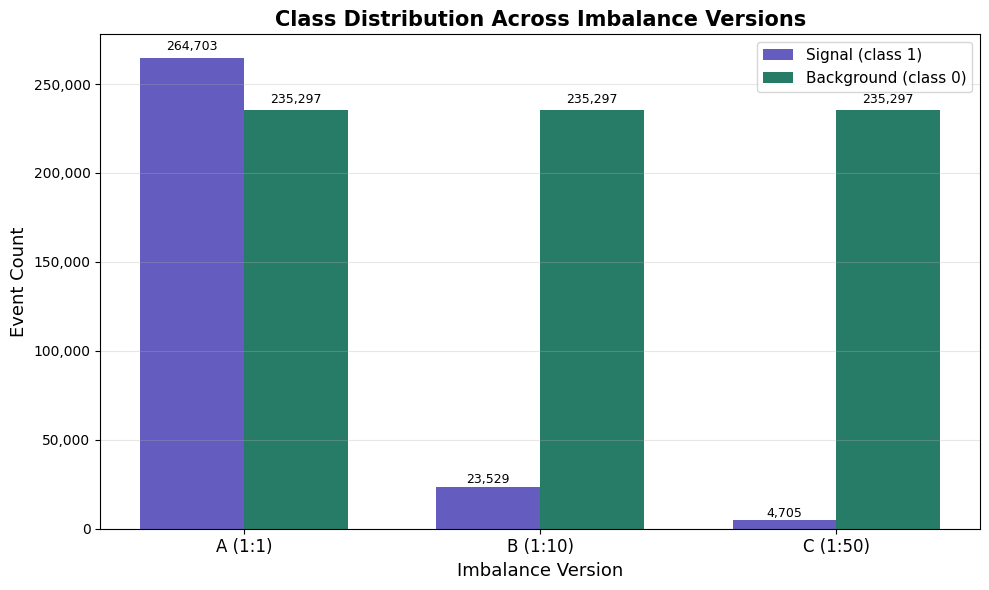

✓ Figure 1 saved → ..\figures\fig1_class_distribution.png


In [4]:
# Figure 1 — Class Distribution
fig, ax   = plt.subplots(figsize=(10, 6))
ver_labels = ['A (1:1)', 'B (1:10)', 'C (1:50)']
x          = np.arange(3)
width      = 0.35

sig_counts = [versions[v]['label'].sum()        for v in ['A','B','C']]
bg_counts  = [(versions[v]['label']==0).sum()   for v in ['A','B','C']]

bars1 = ax.bar(x-width/2, sig_counts, width, label='Signal (class 1)',     color=SIGNAL_COLOR,     alpha=0.9)
bars2 = ax.bar(x+width/2, bg_counts,  width, label='Background (class 0)', color=BACKGROUND_COLOR, alpha=0.9)

ax.set_xlabel('Imbalance Version', fontsize=13)
ax.set_ylabel('Event Count', fontsize=13)
ax.set_title('Class Distribution Across Imbalance Versions', fontsize=15, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(ver_labels, fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)

for bar in list(bars1)+list(bars2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'fig1_class_distribution.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure 1 saved → {save_path}")

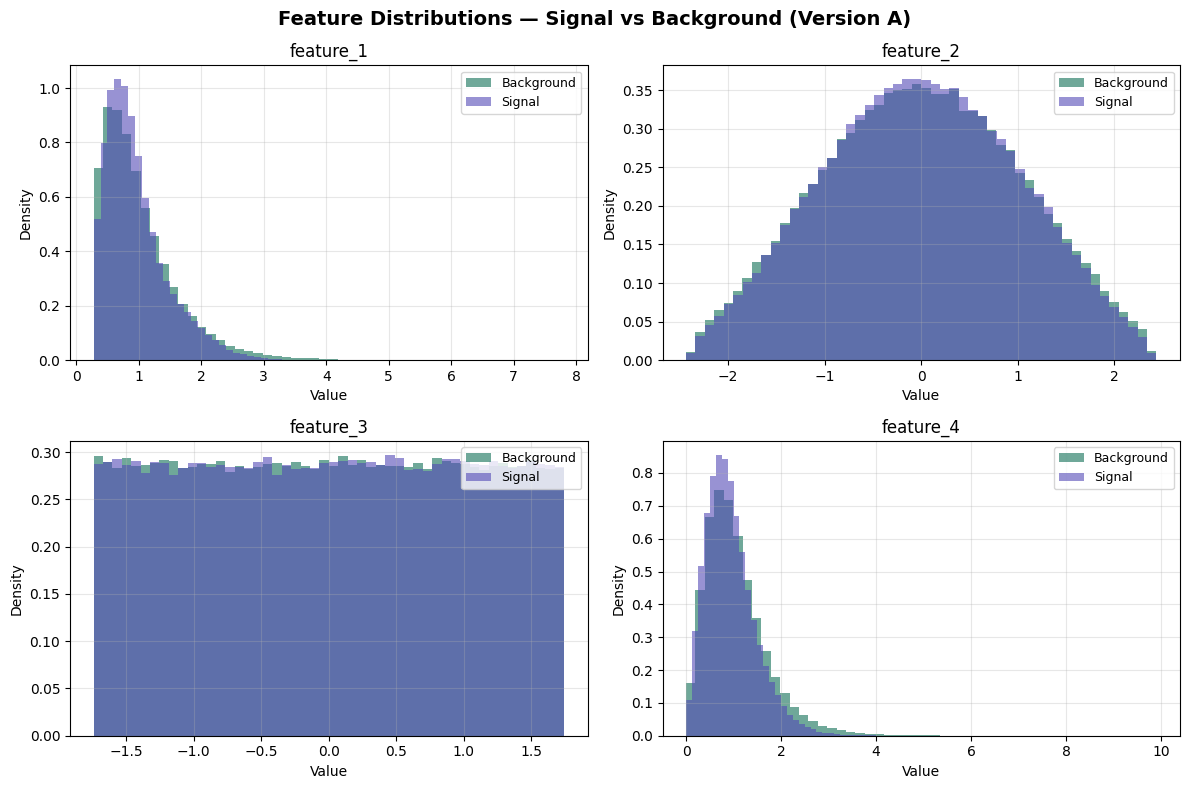

✓ Figure 7 saved → ..\figures\fig7_feature_distributions.png


In [5]:
# Figure 7 — Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes      = axes.flatten()
feat_cols = [f'feature_{i}' for i in range(1, 5)]

for i, col in enumerate(feat_cols):
    sig_data = train_A[train_A['label']==1][col]
    bg_data  = train_A[train_A['label']==0][col]
    axes[i].hist(bg_data,  bins=50, color=BACKGROUND_COLOR, alpha=0.6, label='Background', density=True)
    axes[i].hist(sig_data, bins=50, color=SIGNAL_COLOR,     alpha=0.6, label='Signal',     density=True)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9); axes[i].grid(alpha=0.3)

fig.suptitle('Feature Distributions — Signal vs Background (Version A)', fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'fig7_feature_distributions.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure 7 saved → {save_path}")